# Séries Temporais com LSTM

https://medium.com/datarisk-io/introdu%C3%A7%C3%A3o-%C3%A0s-redes-lstm-prevendo-valor-de-a%C3%A7%C3%B5es-na-bolsa-df270ca0cee5

Buscando dados atualizados para PETR4.SA até 2026-03-06...


[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Registros de Treino: 1624 | Registros de Teste (Recentes): 407

Treinando o modelo com dados recentes...
Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0598
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0056
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - loss: 0.0046
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - loss: 0.0039
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0042
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0039
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - loss: 0.0033
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.0030
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - loss: 0.0028
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0026
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 0.0026
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.0025
Epoch 13/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0022
Epoch 14/50
49/49 ━━━━━━━━━━━━━━━

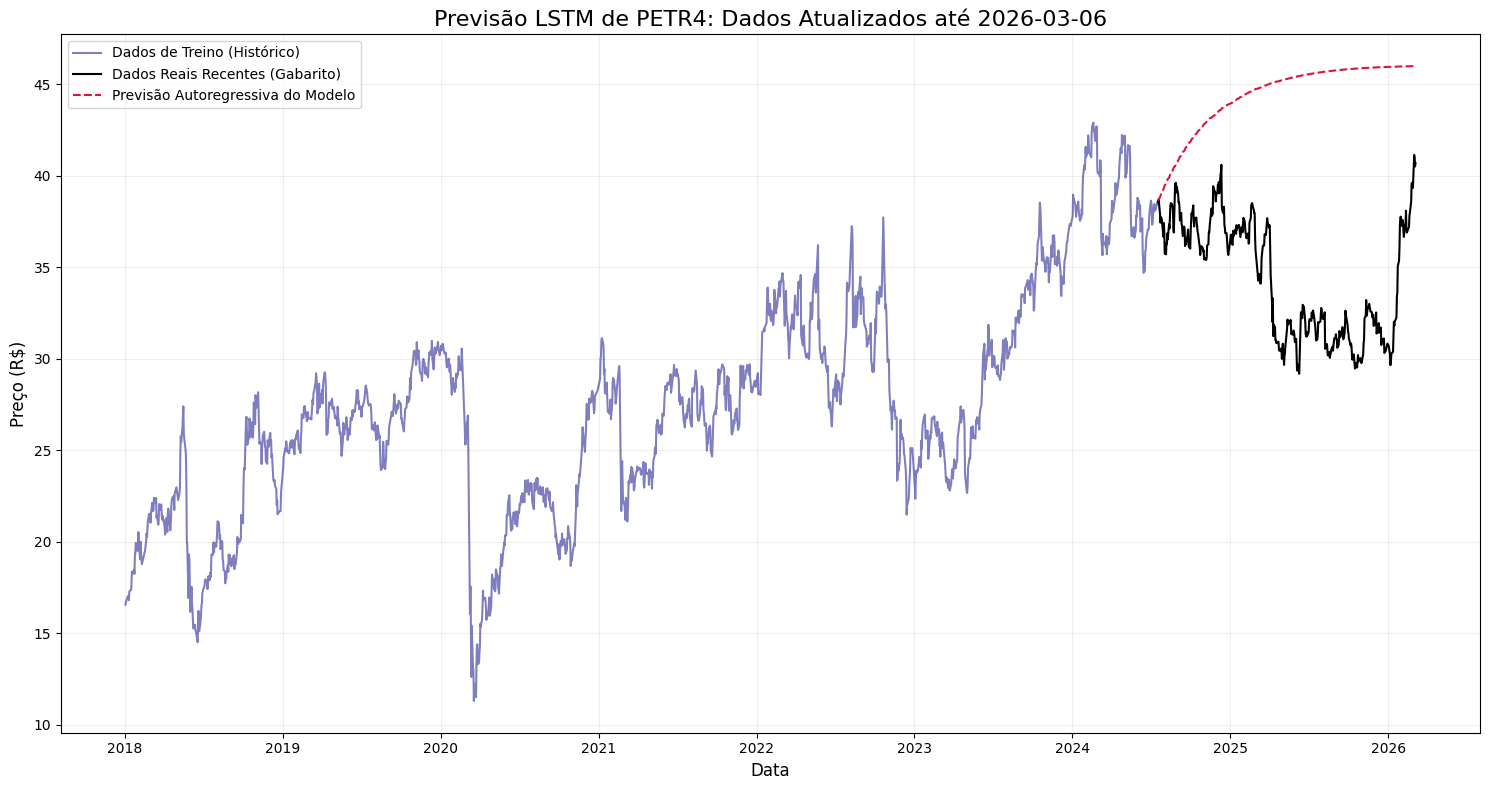

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

ticker = 'PETR4.SA'
hoje = datetime.datetime.now().strftime('%Y-%m-%d')

print(f"Buscando dados atualizados para {ticker} até {hoje}...")

#histórico para o modelo aprender (desde 2018)
df_raw = yf.download(ticker, start='2018-01-01', end=hoje, auto_adjust=False)

# Limpeza de colunas MultiIndex
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.droplevel(1)

df = df_raw[['Close']].dropna()
df.columns = ['Price']

# 80% para treino e 20% para teste (os dados mais recentes)
split_idx = int(len(df) * 0.8)
treino = df.iloc[:split_idx]
teste = df.iloc[split_idx:]

print(f"Registros de Treino: {len(treino)} | Registros de Teste (Recentes): {len(teste)}")

scaler = MinMaxScaler(feature_range=(0, 1))
treino_scaled = scaler.fit_transform(treino)

# PREPARAÇÃO DAS JANELAS (LOOKBACK)
janela = 60 # O modelo olha os últimos 2 meses para prever o próximo dia
X_treino, y_treino = [], []

for i in range(janela, len(treino_scaled)):
    X_treino.append(treino_scaled[i-janela:i, 0])
    y_treino.append(treino_scaled[i, 0])

X_treino, y_treino = np.array(X_treino), np.array(y_treino)
X_treino = np.reshape(X_treino, (X_treino.shape[0], X_treino.shape[1], 1))

# LSTM
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X_treino.shape[1], 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
# Para o treino se o erro parar de cair, evitando decorar o passado (overfitting)
monitor = EarlyStopping(monitor='loss', patience=7, restore_best_weights=True)

print("\nTreinando o modelo com dados recentes...")
model.fit(X_treino, y_treino, epochs=50, batch_size=32, callbacks=[monitor], verbose=1)

# (FORECASTING)
# Começamos com a última janela do treino para prever o início do período de teste
janela_atual = treino_scaled[-janela:].copy()
previsoes_norm = []

for i in range(len(teste)):
    input_model = np.reshape(janela_atual, (1, janela, 1))
    pred = model.predict(input_model, verbose=0)[0, 0]
    previsoes_norm.append(pred)

    # Adicionada a previsão na janela para a próxima iteração
    janela_atual = np.append(janela_atual[1:], [[pred]], axis=0)

previsoes_reais = scaler.inverse_transform(np.array(previsoes_norm).reshape(-1, 1))

# Visualização
mae = mean_absolute_error(teste, previsoes_reais)
rmse = np.sqrt(mean_squared_error(teste, previsoes_reais))

print(f"\n--- Performance nos dados de {hoje} ---")
print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
print(f"Raiz do Erro Quadrático (RMSE): R$ {rmse:.2f}")

plt.figure(figsize=(15, 8))
plt.plot(treino.index, treino['Price'], label='Dados de Treino (Histórico)', color='navy', alpha=0.5)
plt.plot(teste.index, teste['Price'], label='Dados Reais Recentes (Gabarito)', color='black', linewidth=1.5)
plt.plot(teste.index, previsoes_reais, label='Previsão Autoregressiva do Modelo', color='crimson', linestyle='--')

plt.title(f'Previsão LSTM de PETR4: Dados Atualizados até {hoje}', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (R$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

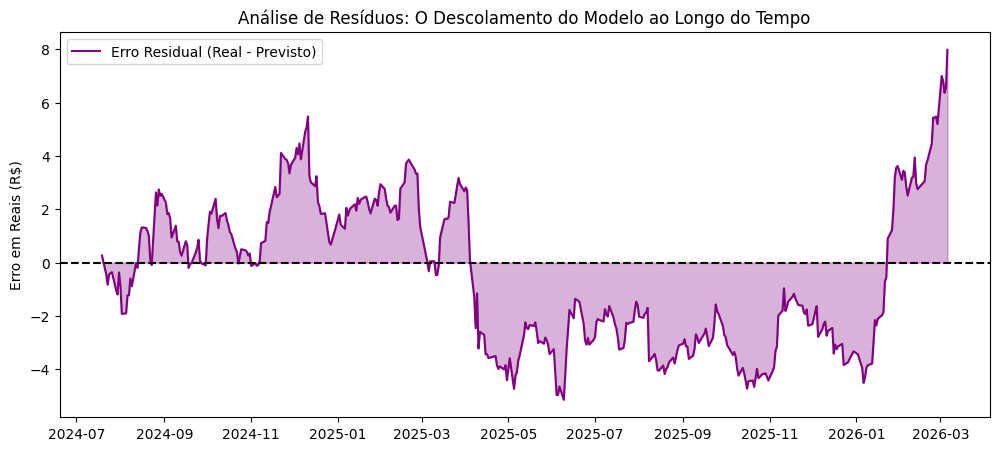

In [ ]:
# Cálculo do erro ponto a ponto
residuos = teste['Price'].values - previsoes_reais.flatten()a
plt.figure(figsize=(12, 5))
plt.plot(teste.index, residuos, color='purple', label='Erro Residual (Real - Previsto)')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Análise de Resíduos: O Descolamento do Modelo ao Longo do Tempo')
plt.ylabel('Erro em Reais (R$)')
plt.fill_between(teste.index, residuos, alpha=0.3, color='purple')
plt.legend()
plt.show()

 O Gráfico mostra que no primeiro mês o erro era pequeno, mas no final de 2025 o erro saltou para R$ 15,00. Isso descreve a perda de relevância da memória da LSTM.

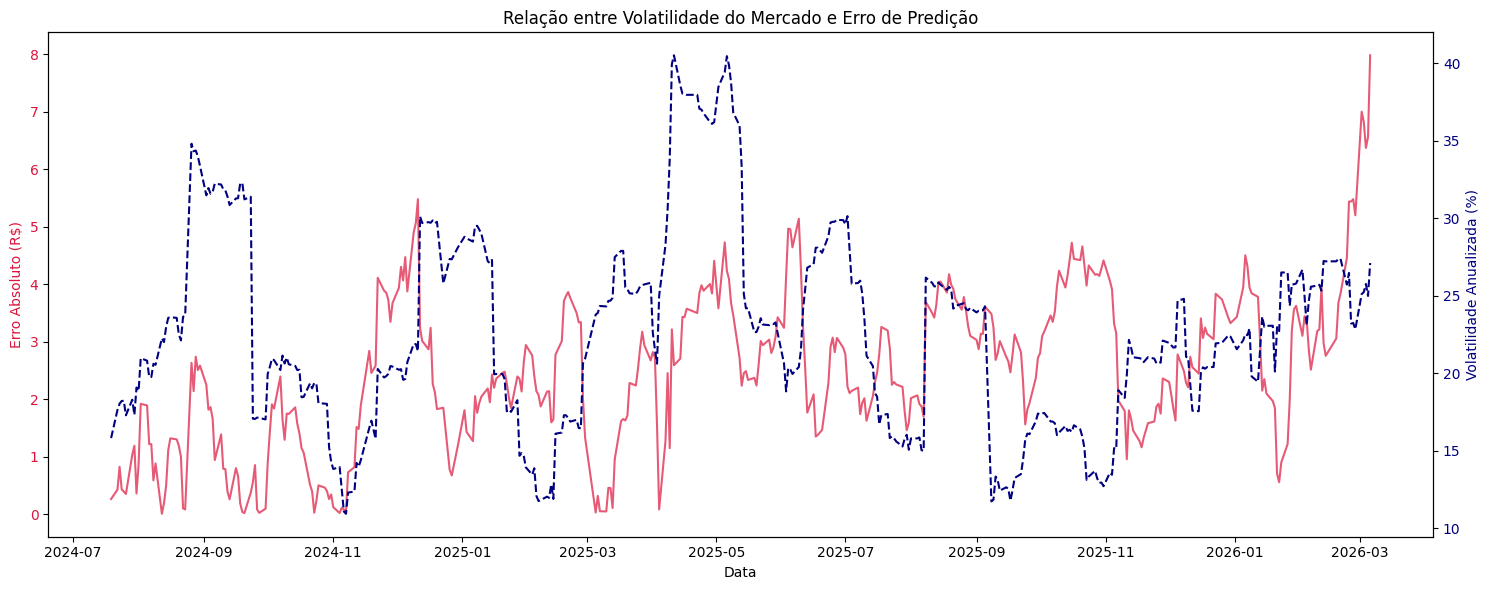

In [ ]:
# Cálculo da Volatilidade Real (Desvio Padrão Móvel de 21 dias)
df['Volatilidade'] = df['Price'].pct_change().rolling(window=21).std() * np.sqrt(252) * 100

# Cálculo do Erro Absoluto Ponto a Ponto no período de teste
erro_ponto_a_ponto = np.abs(teste['Price'].values - previsoes_reais.flatten())

# Visualização da Imprevisibilidade
fig, ax1 = plt.subplots(figsize=(15, 6))

# Eixo 1: O Erro do Modelo
ax1.set_xlabel('Data')
ax1.set_ylabel('Erro Absoluto (R$)', color='crimson')
ax1.plot(teste.index, erro_ponto_a_ponto, color='crimson', label='Erro do Modelo (R$)', alpha=0.7)
ax1.tick_params(axis='y', labelcolor='crimson')

# Eixo 2: A Volatilidade do Mercado
ax2 = ax1.twinx()
ax2.set_ylabel('Volatilidade Anualizada (%)', color='navy')
ax2.plot(teste.index, df['Volatilidade'].loc[teste.index], color='navy', label='Volatilidade do Mercado', linestyle='--')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title('Relação entre Volatilidade do Mercado e Erro de Predição')
fig.tight_layout()
plt.show()

Linha rosa = Erro absoluto


Linha Azul = Volatilidade do mercado

O modelo demonstra ser incapaz de processar o "ruído" do mercado financeiro. Enquanto a volatilidade representa a incerteza e o caos dos eventos reais

A análise prova que a PETR4 não segue um padrão puramente cíclico, pois o mercado reage a eventos externos que a rede LSTM não consegue processar apenas com preços passados.